In [2]:
import os
import cv2
import numpy as np
import shutil
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
# Función para cargar y etiquetar imágenes
from typing import Any


def load_and_label_data(folder, output_folder):
    images = []
    labels = []
    for label, class_folder in enumerate[Any](os.listdir(folder)):
        class_path = os.path.join(folder, class_folder)
        output_class_path = os.path.join(output_folder, class_folder)
        if not os.path.exists(output_class_path):
            os.makedirs(output_class_path)
        print(f"Cargando imágenes de la clase '{class_folder}'...")
        for i, filename in enumerate(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename))

            if img is None:
                print(f"  [!] Error: No se pudo leer '{filename}'. Saltando...")
                continue



            if i < 5:
                # Mostrar imágenes originales y redimensionadas
                fig, axes = plt.subplots(1, 2, figsize=(10, 5))
                axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                axes[0].set_title('Imagen original')

            img_resized = cv2.resize(img, (100, 100))  # Redimensionar según sea necesario
            print(f"Procesando imagen: {filename} (Clase: {class_folder})")

            if i < 5:
                # Mostrar imágenes redimensionadas
                axes[1].imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
                axes[1].set_title('Imagen redimensionada')
                plt.show()

            images.append(img_resized)
            labels.append(label)  # Usar el índice de la clase como etiqueta

            # Guardar imágenes redimensionadas en la nueva carpeta
            output_filename = os.path.join(output_class_path, filename)
            cv2.imwrite(output_filename, img_resized)

    print("Carga y etiquetado completados.")
    return np.array(images), np.array(labels)

Cargando imágenes de la clase 'gato'...
Procesando imagen: 10.jpg (Clase: gato)


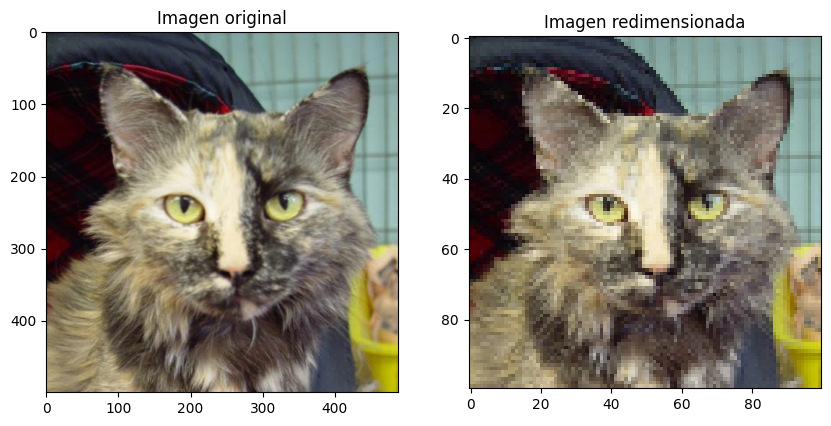

Procesando imagen: cat.4007.jpg (Clase: gato)


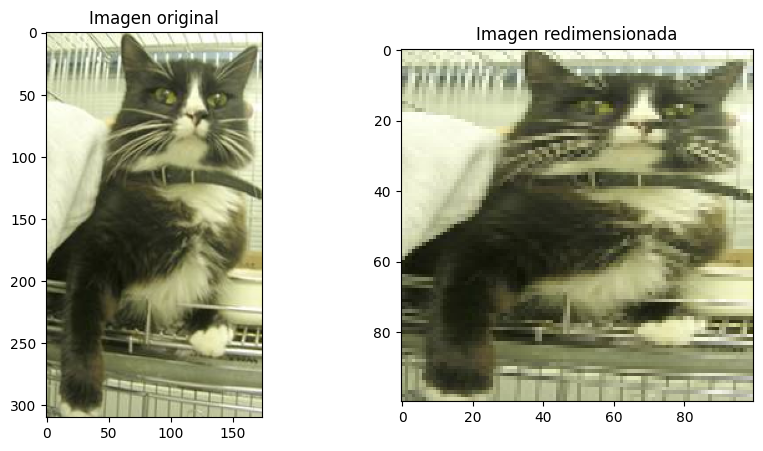

Procesando imagen: closeup-vertical-shot-cute-european-shorthair-cat.jpg (Clase: gato)


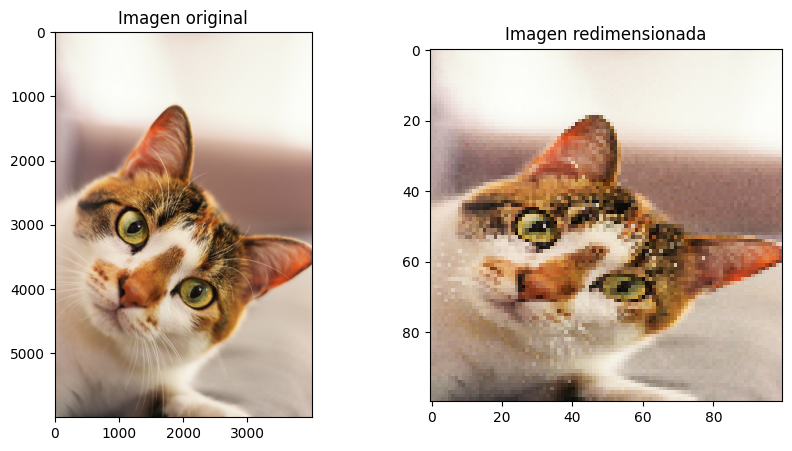

Procesando imagen: cuales-son-razas-gato-mas-caras-del-mundo-872661.jpg (Clase: gato)


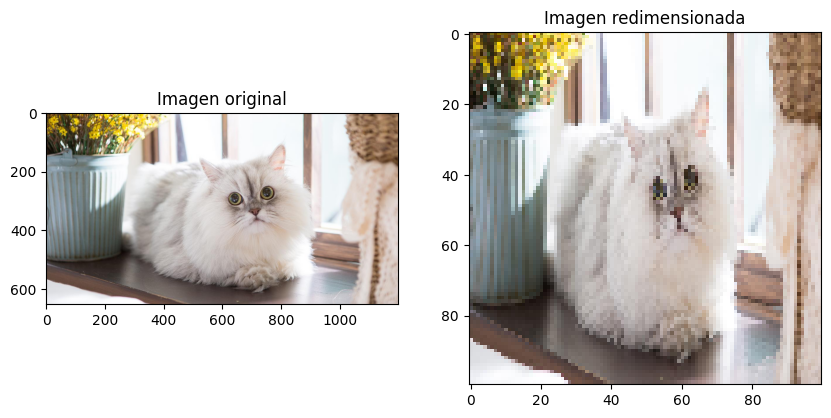

Procesando imagen: Diseno-sin-titulo-26-1.png (Clase: gato)


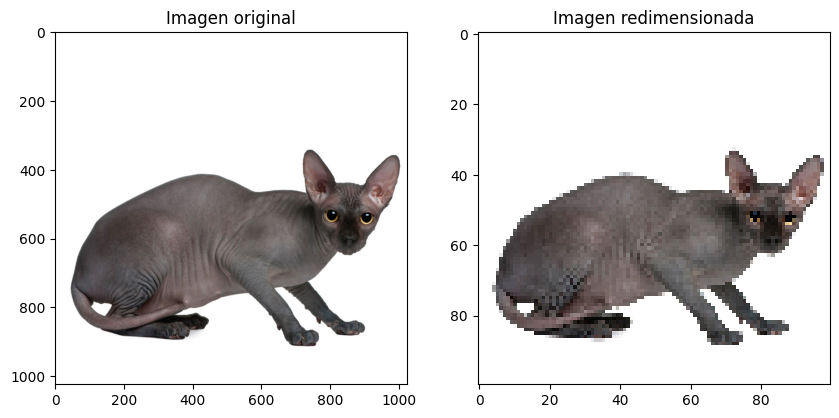

Procesando imagen: el_gato_persa_0323ffdd-8ca6-4757-952d-ffaada1b0c3f.jpg.webp (Clase: gato)
Procesando imagen: Gato 1.jpg (Clase: gato)
Procesando imagen: Gato 2.jpg (Clase: gato)
Procesando imagen: Gato 3.jpg (Clase: gato)
Procesando imagen: Gato 4.jpg (Clase: gato)
Procesando imagen: Gato 5.jpg (Clase: gato)
Procesando imagen: gato-amarillo.png (Clase: gato)
Procesando imagen: gato-bengali-en-tv.jpg (Clase: gato)
  [!] Error: No se pudo leer 'gato-gris-sobre-fondo-blanco_131240-321.jpg'. Saltando...
Procesando imagen: gato-gris.png (Clase: gato)
Procesando imagen: gato-peludo.png (Clase: gato)
Procesando imagen: gato.jpg (Clase: gato)
Procesando imagen: gato1 (1).jpg (Clase: gato)
Procesando imagen: gato1.jpg (Clase: gato)
Procesando imagen: gato2.jpg (Clase: gato)
Procesando imagen: gato3 (1).jpg (Clase: gato)
Procesando imagen: gato3.jpg (Clase: gato)
Procesando imagen: gato4.jpg (Clase: gato)
Procesando imagen: gatoc1.png (Clase: gato)
Procesando imagen: gatoc2.png (Clase: gato)


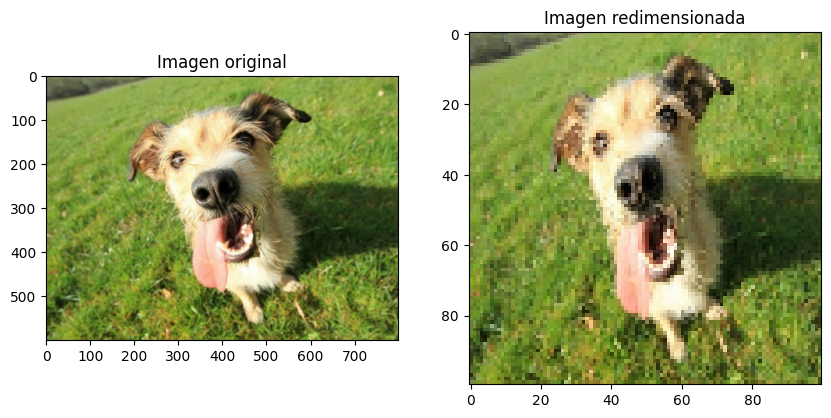

Procesando imagen: alabai-perro.jpg (Clase: perro)


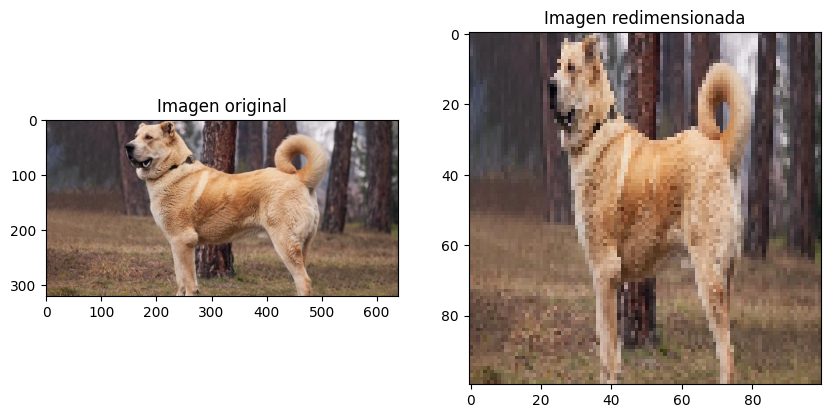

Procesando imagen: alvan-nee-8g0D8ZfFXyA-unsplash.jpg (Clase: perro)


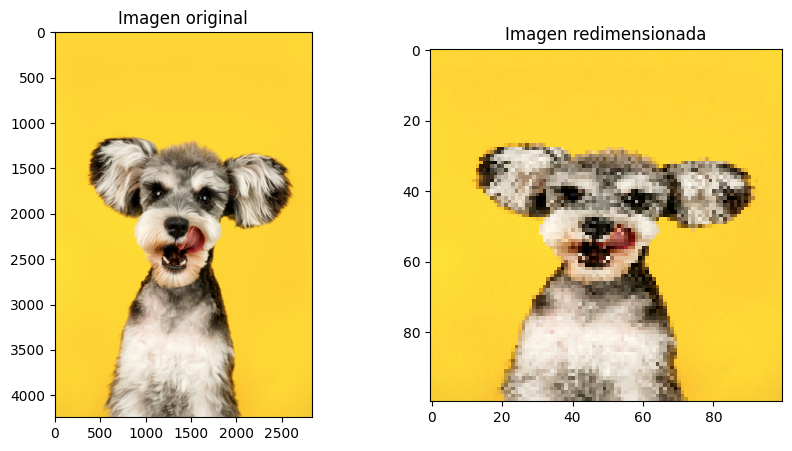

Procesando imagen: alvan-nee-eoqnr8ikwFE-unsplash.jpg (Clase: perro)


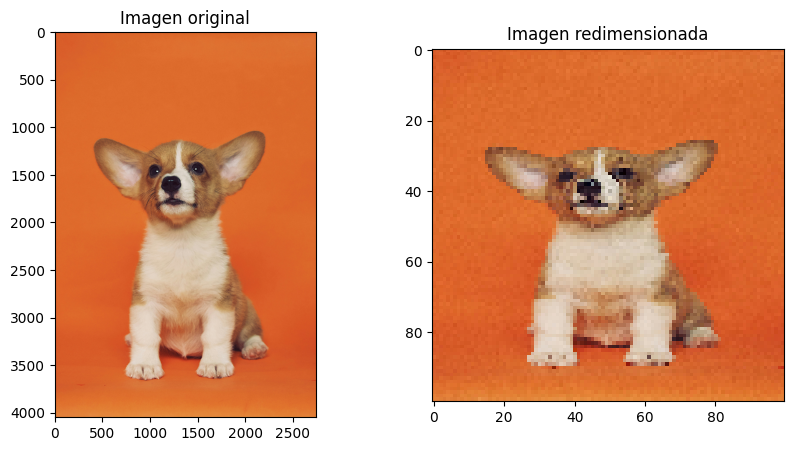

Procesando imagen: cachorro-razas-de-perros-pequenos-y-carinosos-paradispets-800x600.jpg (Clase: perro)


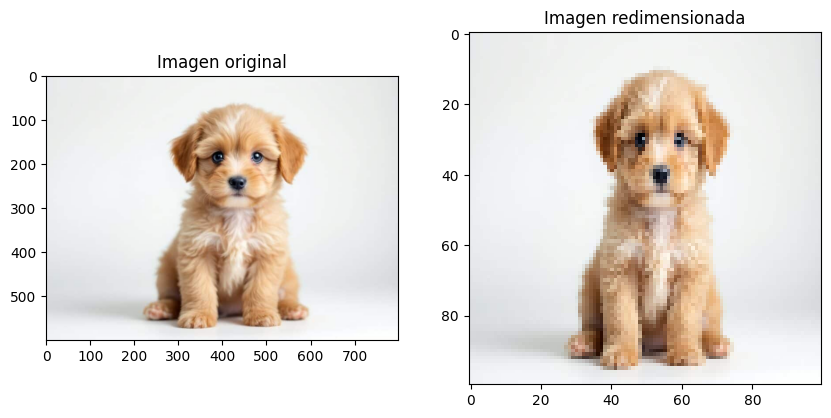

Procesando imagen: close-up-dog-sitting-white-background.jpg (Clase: perro)
  [!] Error: No se pudo leer 'dachshund-8-meses-sentado_191971-4028.avif'. Saltando...
Procesando imagen: david-lezcano-m-Doa-GTrUw-unsplash.jpg (Clase: perro)
Procesando imagen: depositphotos_10886131-stock-photo-old-english-sheepdog-1-year.jpg (Clase: perro)
Procesando imagen: depositphotos_167728872-stock-photo-siberian-husky-puppy-isolated-on.jpg (Clase: perro)
Procesando imagen: depositphotos_321288510-stock-photo-dog-jack-russell-terrier-sitting.jpg (Clase: perro)
Procesando imagen: descargar.webp (Clase: perro)
Procesando imagen: dog-sticking-out-his-tongue-looking-photographer.jpg (Clase: perro)
Procesando imagen: dog.10.jpg (Clase: perro)
Procesando imagen: dog.1004.jpg (Clase: perro)
Procesando imagen: dog.1009.jpg (Clase: perro)
Procesando imagen: dog.101.jpg (Clase: perro)
Procesando imagen: dog.1026.jpg (Clase: perro)
Procesando imagen: dog.1044.jpg (Clase: perro)
Procesando imagen: dog.4009.jpg (C

In [4]:
ruta_path = './DatasetPerrosGatos'
# Directorio que contiene las carpetas de perros y gatos
data_folder = ruta_path

# Carpeta para guardar las imágenes redimensionadas
output_folder = './DatasetRedimensionado'

# Cargar y etiquetar las imágenes y guardar las imágenes redimensionadas
X, y = load_and_label_data(data_folder, output_folder)

ruta_save_dataset='datos_etiquetados_21_02_26.pickle'
# Guardar los datos etiquetados
with open(ruta_save_dataset, 'wb') as handle:
    pickle.dump((X, y), handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Datos etiquetados guardados correctamente.")

# Dividir datos en conjuntos de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ahora X_train, X_test, y_train, y_test están listos para ser utilizados en el entrenamiento de tu modelo

Entrenamiento Red neuronal

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---------- Ajusta esto a tu redimensionamiento ----------
IMG_SIZE = 100  # si ya redimensionaste a 100x100. Si es 500, pon 500.

# Normalizar
X = X.astype("float32") / 255.0

# Arreglar etiquetas a 0/1 y luego one-hot
y = np.array(y)
if y.ndim > 1:
    y = np.argmax(y, axis=-1)
y = y.astype("int32")
y = to_categorical(y, 2)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y.argmax(axis=1)
)

# Asegurar forma (N, IMG_SIZE, IMG_SIZE, 3)
# Si X viene como (N, IMG_SIZE*IMG_SIZE*3) lo rearmamos:
if X_train.ndim == 2:
    X_train = X_train.reshape((-1, IMG_SIZE, IMG_SIZE, 3))
    X_test  = X_test.reshape((-1, IMG_SIZE, IMG_SIZE, 3))

# Construir el modelo CNN (base A, sin aumentar)
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(2, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Entrenar
history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

# Evaluación rápida
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)
print("Test acc:", test_acc)

Epoch 1/10


c:\Users\chexc\Desktop\EjercicioIA\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 477ms/step - accuracy: 0.5385 - loss: 0.7205 - val_accuracy: 0.4286 - val_loss: 0.7783
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6154 - loss: 0.6742 - val_accuracy: 0.5714 - val_loss: 0.6906
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.3846 - loss: 0.6917 - val_accuracy: 0.4286 - val_loss: 0.6989
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5962 - loss: 0.6645 - val_accuracy: 0.4286 - val_loss: 0.7141
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.5962 - loss: 0.6534 - val_accuracy: 0.4286 - val_loss: 0.7411
Test acc: 0.4117647111415863


In [5]:
# Función para aplicar aumentos de datos a una imagen y guardarlas en el mismo directorio
def apply_augmentations_and_save(img, output_folder, filename):
    # Guardar imagen original
    cv2.imwrite(os.path.join(output_folder, f"original_{filename}"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    # Rotar 90 grados y guardar
    rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    cv2.imwrite(os.path.join(output_folder, f"rotated_90_{filename}"), cv2.cvtColor(rotated_90, cv2.COLOR_RGB2BGR))

    # Rotar 180 grados y guardar
    rotated_180 = cv2.rotate(img, cv2.ROTATE_180)
    cv2.imwrite(os.path.join(output_folder, f"rotated_180_{filename}"), cv2.cvtColor(rotated_180, cv2.COLOR_RGB2BGR))

    # Invertir y guardar
    #inverted = cv2.flip(img, -1)
    #cv2.imwrite(os.path.join(output_folder, f"inverted_{filename}"), cv2.cvtColor(inverted, cv2.COLOR_RGB2BGR))

    # Aumento de brillo y guardar
   # brightened = cv2.convertScaleAbs(img, alpha=1.5, beta=50)
    #cv2.imwrite(os.path.join(output_folder, f"brightened_{filename}"), cv2.cvtColor(brightened, cv2.COLOR_RGB2BGR))

    # Modo espejo y guardar
    mirrored = cv2.flip(img, 1)
    cv2.imwrite(os.path.join(output_folder, f"mirrored_{filename}"), cv2.cvtColor(mirrored, cv2.COLOR_RGB2BGR))

# Directorio que contiene las carpetas de perros y gatos
data_folder = './DatasetRedimensionado/'

# Carpeta para guardar las imágenes aumentadas manualmente
output_folder_manual = './DatasetRedimensionadoAumentado'

# Crear carpeta de salida si no existe
if not os.path.exists(output_folder_manual):
    os.makedirs(output_folder_manual)

# Iterar sobre las carpetas de clases
for class_folder in os.listdir(data_folder):
    class_path = os.path.join(data_folder, class_folder)
    output_class_folder = os.path.join(output_folder_manual, class_folder)
    if not os.path.exists(output_class_folder):
        os.makedirs(output_class_folder)
    # Iterar sobre las imágenes en la carpeta de clase
    for filename in os.listdir(class_path):
        img = cv2.imread(os.path.join(class_path, filename))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Aplicar aumentos de datos y guardar las imágenes aumentadas en la carpeta de clase correspondiente
        apply_augmentations_and_save(img, output_class_folder, filename)

print("Aumento de datos manual completado.")

Aumento de datos manual completado.


In [6]:
# Función para cargar y etiquetar imágenes
from typing import Any


def load_and_label_data_aumentado(folder):
    images = []
    labels = []
    for label, class_folder in enumerate[Any](os.listdir(folder)):
        class_path = os.path.join(folder, class_folder)
                  
        
        for i, filename in enumerate(os.listdir(class_path)):
            img = cv2.imread(os.path.join(class_path, filename))

            if img is None:
                print(f"  [!] Error: No se pudo leer '{filename}'. Saltando...")
                continue

            images.append(img)
            labels.append(label)  # Usar el índice de la clase como etiqueta

    print("Carga y etiquetado completados.")
    return np.array(images), np.array(labels)

In [7]:
data_aumentado = './DatasetRedimensionadoAumentado'
# Cargar y etiquetar las imágenes y guardar las imágenes redimensionadas
X_a, y_a = load_and_label_data_aumentado(data_aumentado)

ruta_save_dataset='datos_etiquetados_21_02_26_aumentado.pickle'
# Guardar los datos etiquetados
with open(ruta_save_dataset, 'wb') as handle:
    pickle.dump((X_a, y_a), handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Datos etiquetados guardados correctamente.")

Carga y etiquetado completados.
Datos etiquetados guardados correctamente.


In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Normalizar
X_a = X_a.astype('float32') / 255.0

# Aplanar y_a si ya es one-hot
if y_a.ndim > 1:
    y_a = np.argmax(y_a, axis=1)

# Split
X_a_train, X_a_test, y_a_train_raw, y_a_test_raw = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

y_a_train = to_categorical(y_a_train_raw, 2)
y_a_test  = to_categorical(y_a_test_raw,  2)

# Aplanar
X_a_train_flat = X_a_train.reshape((X_a_train.shape[0], -1))
X_a_test_flat  = X_a_test.reshape((X_a_test.shape[0], -1))

# Modelo mínimo: sin L2, Dropout muy bajo
# Con 265 imágenes totales, menos parámetros = mejor
model_mlp_a = Sequential([
    Dense(256, activation='relu',
          input_shape=(X_a_train_flat.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.1),

    Dense(2, activation='softmax')
])

model_mlp_a.compile(
    optimizer=Adam(learning_rate=0.0001),   # ← lr más bajo para estabilizar
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mlp_a.summary()

# Entrenar
history_mlp_a = model_mlp_a.fit(
    X_a_train_flat, y_a_train,
    epochs=100,
    batch_size=16,                          # ← batch pequeño para 265 imágenes
    validation_data=(X_a_test_flat, y_a_test),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-7)
    ]
)

